# Notebook 3 - Gradient descent, momentum and adaptive methods

Project 1, parts e and f.

Anne Kristin Furu, FYS-STK4155, fall 2026.

## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax import grad
from common import BLUE, RED, YELLOW, GREY, GREEN, SEED, savefig
from Get_data import make_data, polynomial_features, scale_center, split
from helper import ols_ridge_cost, ols_ridge_gradient, hessian_eigs, learning_rate_bounds
from optimisers import optimise, optimiser_step
from OLS import ols_svd
from Ridge import ridge_closed_form
np.set_printoptions(precision=4, suppress=True)

x, y = make_data(n=100, noise=0.1, seed=SEED)

## Part e: gradient descent with analytical and automatic gradients

We fit Runge with gradient descent instead of the closed form. First we check the gradient two ways, then we study the learning rate.

### The gradient two ways

The analytical gradient of the OLS cost is $\frac{2}{n}X^T(X\theta-y)$, and for Ridge it has the extra term $2\lambda\theta$. We compare it with `jax.grad` of the same cost at a random $\theta$. They agree to machine precision.

In [2]:
d = 6
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
lam = 1e-3

def cost_ols(th, X, y):
    return jnp.sum((X @ th - y) ** 2) / len(y)

def cost_ridge(th, X, y, lam):
    return jnp.sum((X @ th - y) ** 2) / len(y) + lam * jnp.sum(th ** 2)

rng = np.random.default_rng(1)
th = rng.standard_normal(Xtr.shape[1])
Xj, yj = jnp.asarray(Xtr), jnp.asarray(ytr)

g_ad_ols = np.asarray(grad(cost_ols)(th, Xj, yj))
g_an_ols = ols_ridge_gradient(th, Xtr, ytr, 0.0)
g_ad_ridge = np.asarray(grad(cost_ridge)(th, Xj, yj, lam))
g_an_ridge = ols_ridge_gradient(th, Xtr, ytr, lam)
print('OLS   max |AD - analytical| =', np.max(np.abs(g_ad_ols - g_an_ols)))
print('Ridge max |AD - analytical| =', np.max(np.abs(g_ad_ridge - g_an_ridge)))

OLS   max |AD - analytical| = 1.7763568394002505e-15
Ridge max |AD - analytical| = 1.7763568394002505e-15


Automatic differentiation is neither symbolic nor finite-difference. It applies the exact chain rule through the code, with no closed-form expression and no step size, so the result is exact. In reverse mode a full gradient costs about two or three cost evaluations whatever the number of parameters. Because the two gradients agree, gradient descent gives the same iterates with either one.

### Learning rate and the eigenvalues of the Hessian

On the degree-4 problem we run plain gradient descent for several learning rates and compare with the closed-form OLS solution. Section 4.5 says gradient descent converges only for $\gamma < 2/\lambda_{\max}$, is fastest at $\gamma^\ast = 2/(\lambda_{\max}+\lambda_{\min})$, and slows down as the condition number grows. We verify the stability edge numerically.

degree 4: kappa=64.5, gamma_max=0.3930, gamma*=0.3870


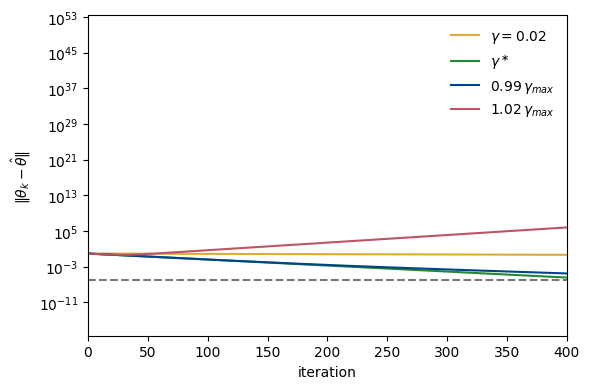

In [3]:
d = 4
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
theta_hat = ols_svd(Xtr, ytr)
gmax, gstar, kappa = learning_rate_bounds(Xtr)
print(f'degree {d}: kappa={kappa:.1f}, gamma_max={gmax:.4f}, gamma*={gstar:.4f}')

grad_fn = lambda th: ols_ridge_gradient(th, Xtr, ytr, 0.0)
gammas = [0.02, gstar, 0.99 * gmax, 1.02 * gmax]
labels = [r'$\gamma=0.02$', r'$\gamma^\ast$', r'$0.99\,\gamma_{max}$', r'$1.02\,\gamma_{max}$']
cols = [YELLOW, GREEN, BLUE, RED]

fig, ax = plt.subplots(figsize=(6, 4))
for g, lab, col in zip(gammas, labels, cols):
    hist, _ = optimise(grad_fn, np.zeros(Xtr.shape[1]), 'plain', g, num_iters=3000, tol=0.0)
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    ax.semilogy(dist, color=col, label=lab)
ax.set_xlim(0, 400)
ax.axhline(1e-6, ls='--', color=GREY)
ax.set_xlabel('iteration')
ax.set_ylabel(r'$\|\theta_k - \hat\theta\|$')
ax.legend(frameon=False)
fig.tight_layout()
savefig('e_learning_rate', fig)
plt.show()

The straight lines on the log scale are geometric convergence. The fastest rate is $\gamma^\ast$. Just below the stability edge, $0.99\,\gamma_{max}$, it still converges; just above, $1.02\,\gamma_{max}$, it diverges. The edge is set by the largest eigenvalue of the Hessian, a property of the data, not of the algorithm, so we compute it before choosing the step.

## Part f: momentum, AdaGrad, RMSProp and Adam

We extend gradient descent with momentum and the adaptive methods, and compare them on the harder degree-6 Runge problem, where the condition number is about 2000 and plain gradient descent is slow.

degree 6: kappa=2090
plain     gamma=0.2339 -> 17144 iters to 1e-6
momentum  gamma=0.2339 -> 1572 iters to 1e-6


adagrad   gamma=0.1000 -> did not reach 1e-6
rmsprop   gamma=0.1000 -> did not reach 1e-6


adam      gamma=0.1000 -> 1280 iters to 1e-6


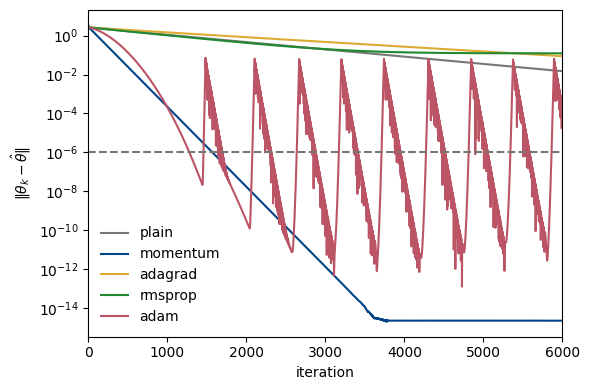

In [4]:
d = 6
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
theta_hat = ols_svd(Xtr, ytr)
gmax, gstar, kappa = learning_rate_bounds(Xtr)
grad_fn = lambda th: ols_ridge_gradient(th, Xtr, ytr, 0.0)
print(f'degree {d}: kappa={kappa:.0f}')

def iters_to(hist, tol=1e-6):
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    hit = np.argmax(dist < tol)
    return int(hit) if dist[hit] < tol else None

runs = [('plain', 0.9 * gmax), ('momentum', 0.9 * gmax),
        ('adagrad', 0.1), ('rmsprop', 0.1), ('adam', 0.1)]
cols = {'plain': GREY, 'momentum': BLUE, 'adagrad': YELLOW, 'rmsprop': GREEN, 'adam': RED}

fig, ax = plt.subplots(figsize=(6, 4))
for method, g in runs:
    hist, _ = optimise(grad_fn, np.zeros(Xtr.shape[1]), method, g, num_iters=20000, tol=0.0)
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    k = iters_to(hist)
    print(f'{method:9s} gamma={g:.4f} -> ' + (f'{k} iters to 1e-6' if k else 'did not reach 1e-6'))
    ax.semilogy(dist, color=cols[method], label=method)
ax.set_xlim(0, 6000)
ax.axhline(1e-6, ls='--', color=GREY)
ax.set_xlabel('iteration')
ax.set_ylabel(r'$\|\theta_k - \hat\theta\|$')
ax.legend(frameon=False)
fig.tight_layout()
savefig('f_optimisers', fig)
plt.show()

Momentum and Adam reach the closed-form solution in far fewer iterations than plain gradient descent. RMSProp at a constant learning rate does not reach the tight tolerance, because near the minimum its step is about $\gamma$ times the sign of the gradient, a fixed length that cannot shrink, so the iterate rattles at a radius set by $\gamma$.

### Sensitivity to the learning rate

For each method we scan the learning rate and record the iterations to reach the tolerance. The adaptive methods work over a much wider range of $\gamma$, since their step is at most $\gamma$ per coordinate and cannot cross the stability edge that limits plain gradient descent.

/usr/local/lib/python3.11/dist-packages/numpy/linalg/_linalg.py:2803: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/usr/local/lib/python3.11/dist-packages/numpy/linalg/_linalg.py:2804: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


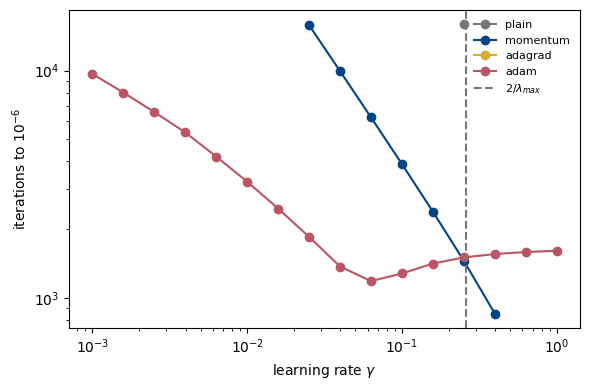

In [5]:
gammas = np.geomspace(1e-3, 1.0, 16)
fig, ax = plt.subplots(figsize=(6, 4))
for method in ('plain', 'momentum', 'adagrad', 'adam'):
    its = []
    for g in gammas:
        with np.errstate(over='ignore', invalid='ignore'):
            hist, _ = optimise(grad_fn, np.zeros(Xtr.shape[1]), method, g, num_iters=20000, tol=0.0)
        k = iters_to(hist)
        its.append(np.nan if k is None else k)
    ax.loglog(gammas, its, 'o-', color=cols[method], label=method)
ax.axvline(2 / hessian_eigs(Xtr).max(), ls='--', color=GREY, label=r'$2/\lambda_{max}$')
ax.set_xlabel(r'learning rate $\gamma$')
ax.set_ylabel('iterations to $10^{-6}$')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
savefig('f_lr_sensitivity', fig)
plt.show()

Plain gradient descent has a narrow window that ends at $2/\lambda_{\max}$. Momentum reaches a little further and is faster at its best. Adam converges across the whole range and is the least sensitive to $\gamma$, which is why it transfers well between problems.

## Summary of parts e and f

The analytical and automatic gradients agree to machine precision, so either can drive gradient descent. Plain gradient descent is governed by the eigenvalues of the Hessian: the step must stay below $2/\lambda_{\max}$ and the iteration count grows with the condition number. Momentum and the adaptive methods, especially Adam, converge faster and tolerate a wider range of learning rates, which matters on the ill-conditioned high-degree Runge problem.